In [240]:
#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
#--------------THIS PART OF CODE WILL BE USED TO LATER EVALUATE THE SUBMITTED ASSIGNMENT--------------#
import sys
if len(sys.argv) != 2:
    print("Usage: python your_program.py <filename>")
    sys.exit(1)
file = sys.argv[1]

Usage: python your_program.py <filename>


SystemExit: 1

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [242]:
file = "TeamCipher.h5"  #put the path of the downloaded h5 file which was assigned to your team

#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
import h5py
import numpy as np
with h5py.File(file, "r") as hf:
    trace_array = np.array(hf["trace_array"])
    textin_array = np.array(hf["textin_array"])
    textout_array = np.array(hf["textout_array"])
    key_array = np.array(hf["key_array"])

sbox = [
    # 0    1    2    3    4    5    6    7    8    9    a    b    c    d    e    f
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76, # 0
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0, # 1
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15, # 2
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75, # 3
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84, # 4
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf, # 5
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8, # 6
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2, # 7
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73, # 8
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb, # 9
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79, # a
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08, # b
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a, # c
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e, # d
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf, # e
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16  # f
]
print(trace_array.shape)
print('plaintext:',textin_array[0])
print('actual key:',key_array[0])
print('ciphertext:',textout_array[0])

(50, 5250)
plaintext: [153  86   0 142 162 248  37 253   2 143 137  28 241 231 130 105]
actual key: [ 24 111 181 111 233  50 246 104   1 132   6 120 225  63  74 150]
ciphertext: [115 248 110  95 103 198 119  97 218 220 243 200 253 250  52 195]


**Analyzing Noise**

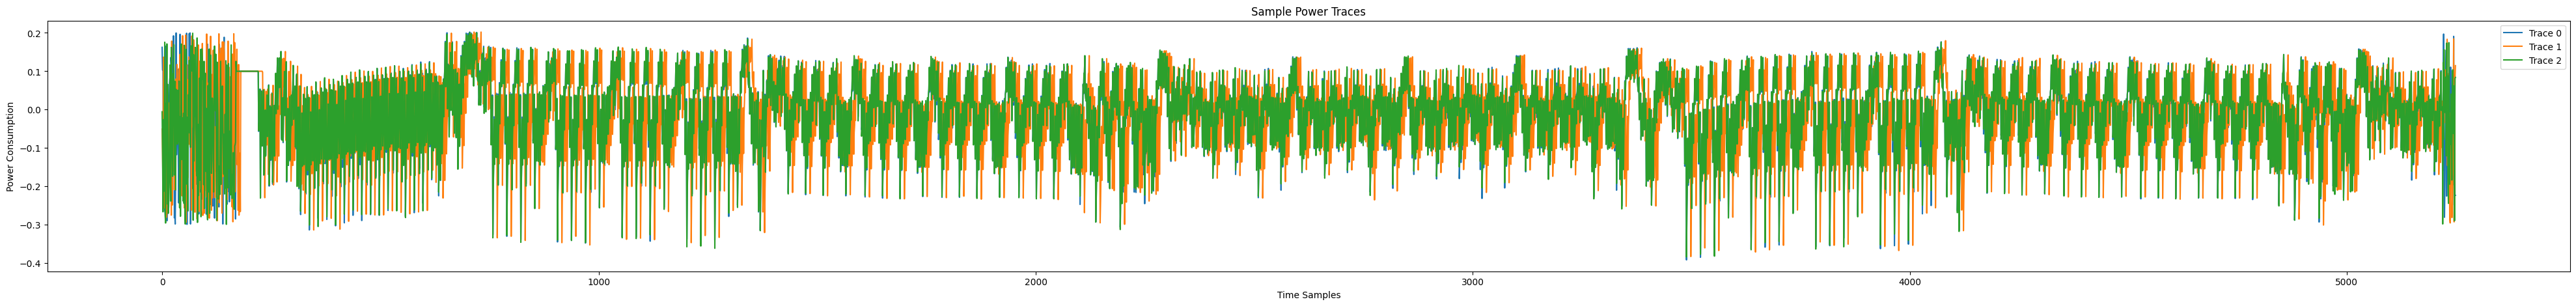

In [243]:
# Plot with noise
import matplotlib.pyplot as plt
plt.figure(figsize=(50, 5))
num_samples_to_plot = 3  # Change this to plot more traces

for i in range(num_samples_to_plot):
    plt.plot(trace_array[i][:5250], label=f"Trace {i}")

plt.xlabel("Time Samples")
plt.ylabel("Power Consumption")
plt.title("Sample Power Traces")
plt.legend()
plt.show()


In [244]:
for i in range(len(trace_array[0])):
  print(i, " : ", trace_array[0][i])

# Index range for constant power values = [170, 219]
# Hence, in noise removal, we have taken the 5000 power values after the last noise point, for each trace

0  :  0.16244201872963127
1  :  0.1029807403523722
2  :  0.10181347188149048
3  :  -0.12862968907053396
4  :  -0.20071972942942096
5  :  0.019750781340577617
6  :  -0.2632248849881673
7  :  -0.269888371514962
8  :  -0.28845779066814037
9  :  0.16572764375575427
10  :  0.12804202709193274
11  :  -0.2896828603275307
12  :  -0.07539510713768127
13  :  -0.27060989624961024
14  :  -0.010815980954662852
15  :  -0.08324095571554929
16  :  0.013500794143579298
17  :  0.06989722067080395
18  :  0.08532124791675655
19  :  0.03160253509614708
20  :  0.13607046213893992
21  :  0.1149720941153799
22  :  -0.1529932520638756
23  :  -0.019135001077438873
24  :  0.13829831979000323
25  :  0.030492922466122785
26  :  0.19237322410677932
27  :  0.08557153598777567
28  :  -0.2817747926844316
29  :  -0.2731831201174126
30  :  -0.29802764907381735
31  :  -0.16842459694116235
32  :  0.19978001225702585
33  :  -0.11755048749755076
34  :  -0.06107290732251647
35  :  -0.011583358956692213
36  :  0.1050323801219

In [245]:
trace_array_without_noise_removal = trace_array # used later for CPA attack without noise removal
print(trace_array_without_noise_removal.shape)

(50, 5250)


**Noise Removal**

In [ ]:
def remove_constant_ranges(trace):
    # Step 1: Remove consecutive duplicates while keeping the last occurrence
    condensed_trace = []
    # start_index = 0
    for i in range(1, len(trace)):
        if trace[i] == 0.1 and trace[i+1] != 0.1:
            start_index = i+1
    print(start_index)
    for i in range(start_index, start_index+5000):
        condensed_trace.append(trace[i])

    return condensed_trace, start_index, start_index+5000

In [247]:
# Removing noise points from each trace
noiseless_array = []
for i in range(50):
  noiseless_trace, _, _ = remove_constant_ranges(trace_array[i])
  noiseless_array.append(noiseless_trace)

noiseless_array = np.array(noiseless_array)
print(noiseless_array.shape)


220
230
220
228
244
244
226
204
240
234
243
233
240
221
221
229
206
229
201
206
250
204
232
235
245
242
244
244
234
210
225
212
245
233
228
236
201
215
214
214
212
213
238
234
240
243
231
240
203
239
(50, 5000)


In [248]:
trace_array = np.array(noiseless_array) # trace_array contains the noiseless power trace, size = (50, 5000)
print(trace_array.shape)

(50, 5000)


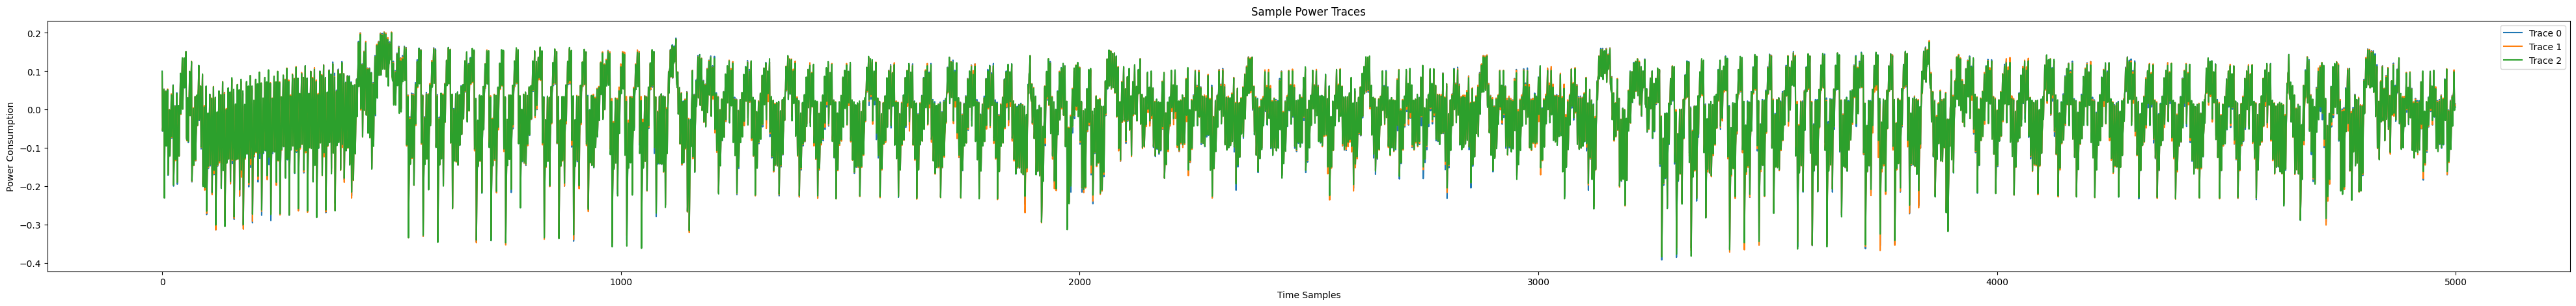

In [249]:
# Plot after removing the noise
import matplotlib.pyplot as plt
plt.figure(figsize=(50, 5))
num_samples_to_plot = 3  # Change this to plot more traces

for i in range(num_samples_to_plot):
    plt.plot(trace_array[i][:5250], label=f"Trace {i}")

plt.xlabel("Time Samples")
plt.ylabel("Power Consumption")
plt.title("Sample Power Traces")
plt.legend()
plt.show()


**CPA attack**

In [250]:

def getCorrelation(hPower, trace):

    meanH = np.mean(hPower, axis=0)
    meanTrace = np.mean(trace, axis=0)

    mat1 = hPower - meanH[np.newaxis, :]
    mat2 = trace - meanTrace[np.newaxis, :]

    numerator = np.sum(mat1[:, :, np.newaxis] * mat2[:, np.newaxis, :], axis=0)

    denominator = np.sum(mat1**2, axis=0)[:, np.newaxis] * np.sum(mat2**2, axis=0)[np.newaxis, :]

    C = numerator/np.sqrt(denominator)
    return C

**[A] CPA attack without noise removal**

In [251]:
import numpy as np

# CPA Attack Implementation
num_traces, num_samples = trace_array_without_noise_removal.shape  # (Number of traces, Number of sample points)
num_keys = 256  # AES key bytes range from 0 to 255

key_guesses = np.zeros(16, dtype=int)

for byte in range(16):  # AES has 16 key bytes
    correlation = np.zeros(num_keys)

    # Hypothetical values matrix (50, 256) → one row per trace, one column per key guess
    hypothetical_values = np.zeros((num_traces, num_keys))

    for key_guess in range(num_keys):
        hypothetical_values[:, key_guess] = [sbox[textin_array[i][byte] ^ key_guess] for i in range(num_traces)]

    # Convert to Hamming Weight Model
    hw_model = np.vectorize(lambda x: bin(int(x)).count("1"))(hypothetical_values)  # Shape: (50, 256)

    # Compute correlation for each key hypothesis
    max_correlation = np.zeros(num_keys)

    correlation_matrix = getCorrelation(hw_model, trace_array_without_noise_removal)
    best_correlation_per_key = np.max(np.abs(correlation_matrix), axis=1)
    # print(",,,,", best_correlation_per_key)
    # Find the best key byte
    key_guesses[byte] = np.argmax(best_correlation_per_key)
    print(f"Best guess for key byte {byte}: {(key_guesses[byte])} , actual keybyte: {key_array[0][byte]}")

Best guess for key byte 0: 24 , actual keybyte: 24
Best guess for key byte 1: 233 , actual keybyte: 111
Best guess for key byte 2: 32 , actual keybyte: 181
Best guess for key byte 3: 242 , actual keybyte: 111
Best guess for key byte 4: 12 , actual keybyte: 233
Best guess for key byte 5: 234 , actual keybyte: 50
Best guess for key byte 6: 206 , actual keybyte: 246
Best guess for key byte 7: 199 , actual keybyte: 104
Best guess for key byte 8: 69 , actual keybyte: 1
Best guess for key byte 9: 19 , actual keybyte: 132
Best guess for key byte 10: 167 , actual keybyte: 6
Best guess for key byte 11: 103 , actual keybyte: 120
Best guess for key byte 12: 15 , actual keybyte: 225
Best guess for key byte 13: 77 , actual keybyte: 63
Best guess for key byte 14: 4 , actual keybyte: 74
Best guess for key byte 15: 128 , actual keybyte: 150


In [252]:
#Evaluating accuracy

# Counting the number of correctly guessed bytes
correct_guesses = sum(key_guesses[i] == key_array[0][i] for i in range(len(key_array[0])))
accuracy = (correct_guesses / 16) * 100

print(f"\nCPA Attack Accuracy: {accuracy:.2f}%")


CPA Attack Accuracy: 6.25%


**[B] CPA attack with noise removal**

Best guess for key byte 0: 24 , actual keybyte: 24


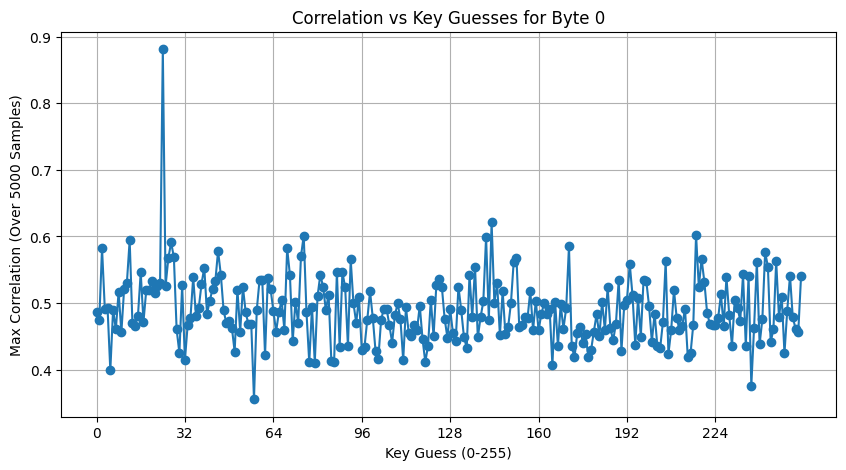

Best guess for key byte 1: 111 , actual keybyte: 111


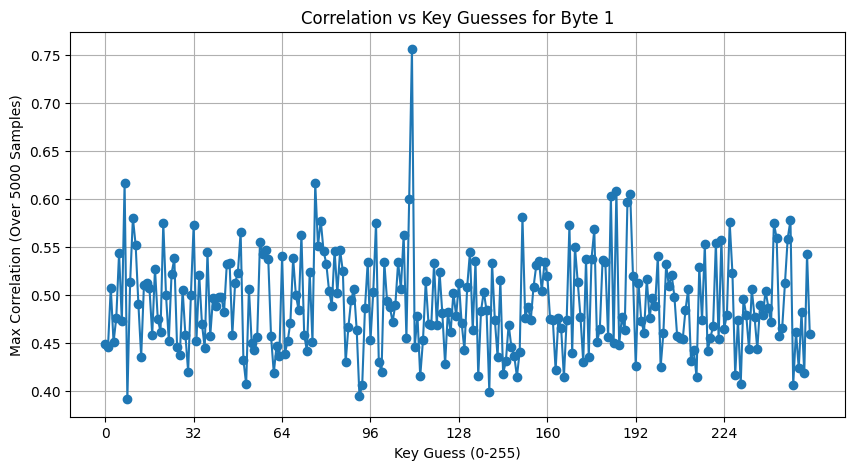

Best guess for key byte 2: 181 , actual keybyte: 181


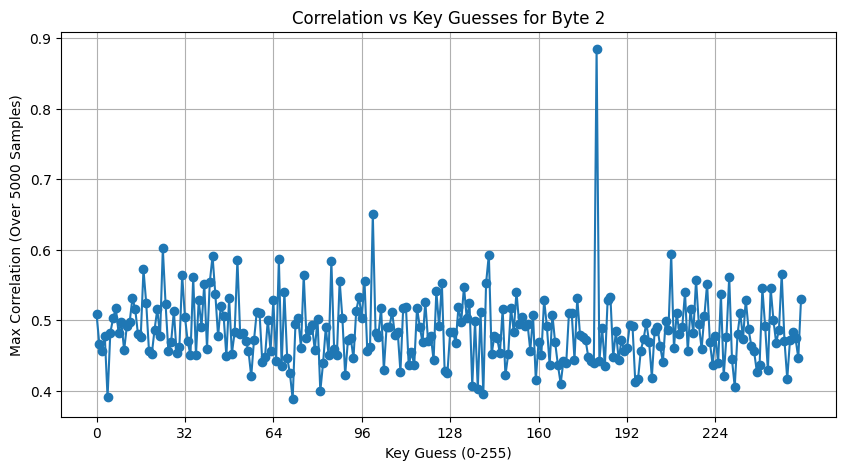

Best guess for key byte 3: 111 , actual keybyte: 111


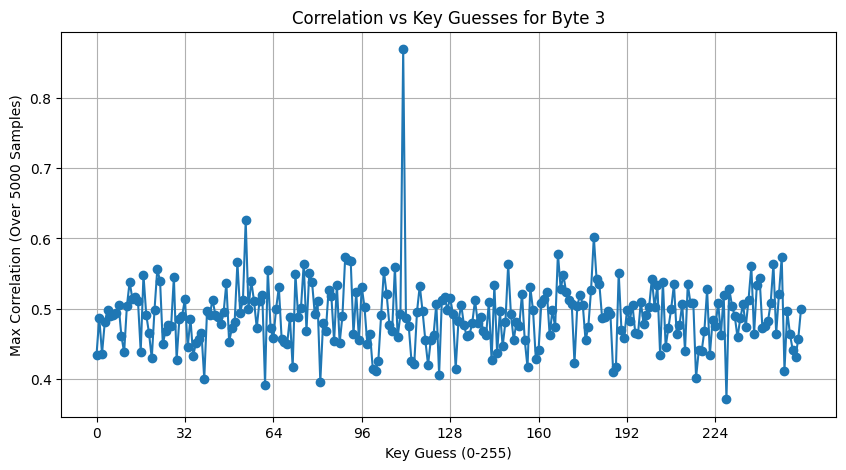

Best guess for key byte 4: 233 , actual keybyte: 233


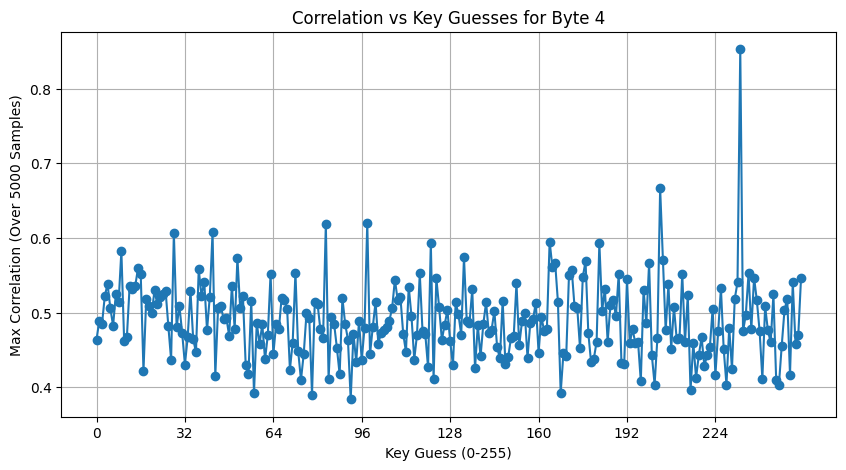

Best guess for key byte 5: 50 , actual keybyte: 50


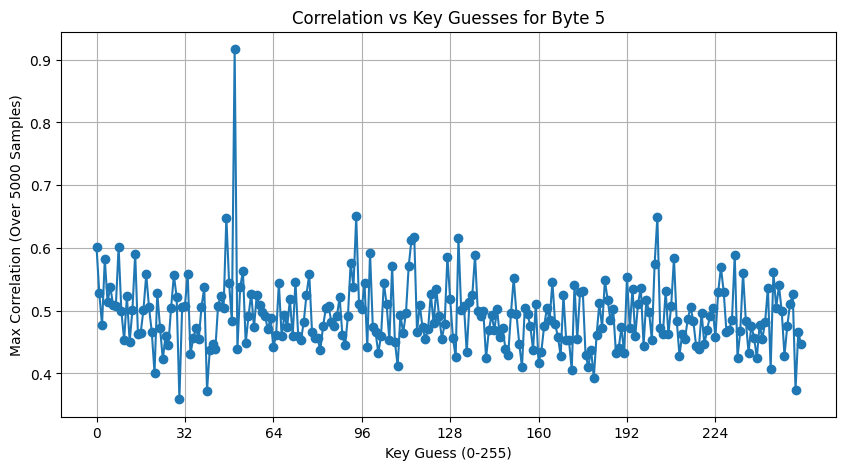

Best guess for key byte 6: 246 , actual keybyte: 246


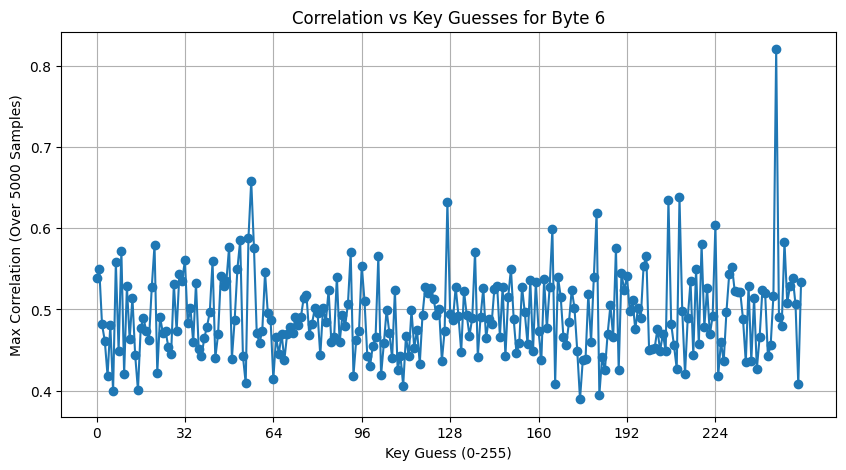

Best guess for key byte 7: 104 , actual keybyte: 104


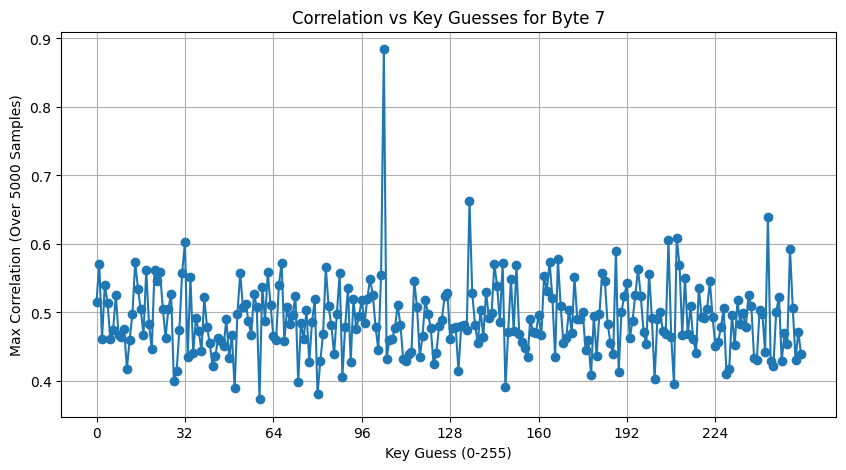

Best guess for key byte 8: 1 , actual keybyte: 1


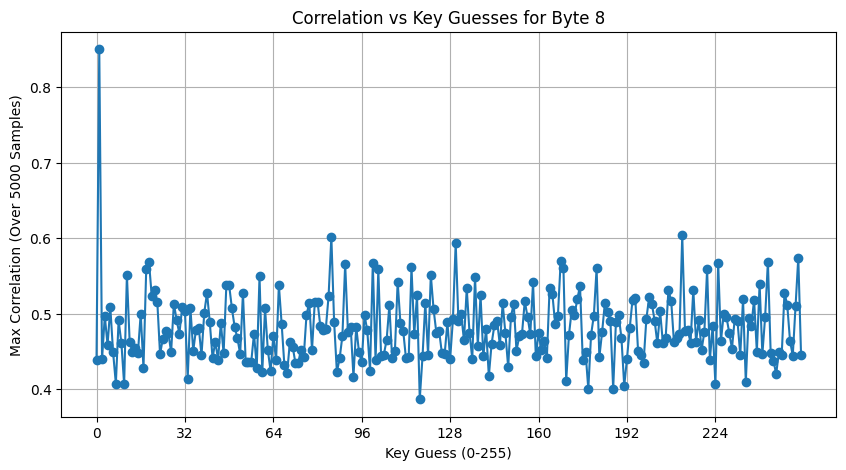

Best guess for key byte 9: 132 , actual keybyte: 132


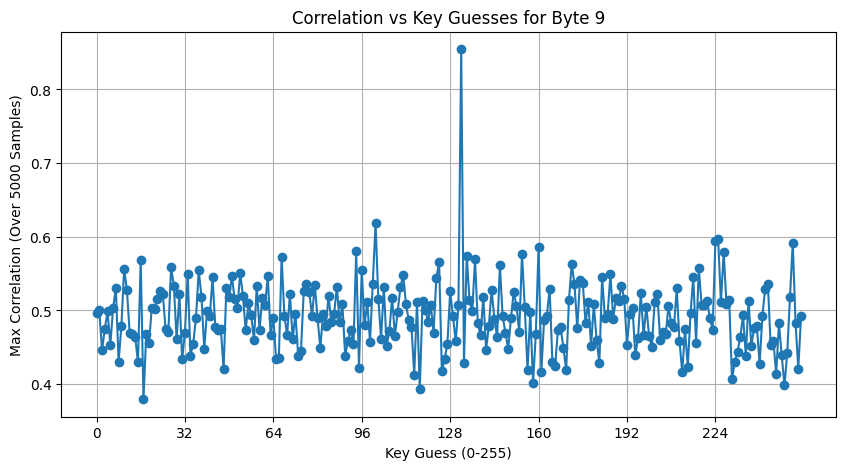

Best guess for key byte 10: 6 , actual keybyte: 6


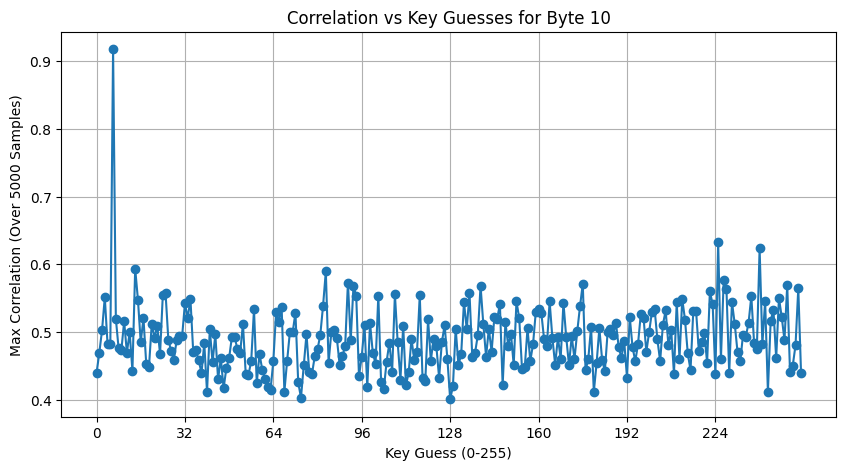

Best guess for key byte 11: 120 , actual keybyte: 120


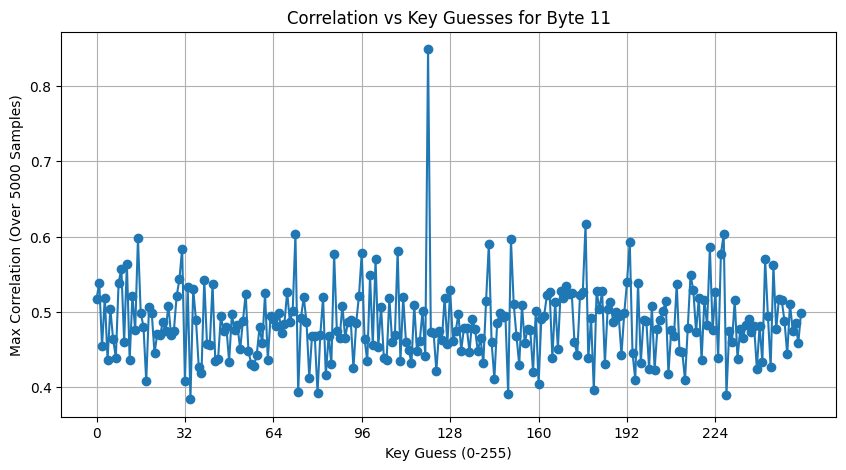

Best guess for key byte 12: 225 , actual keybyte: 225


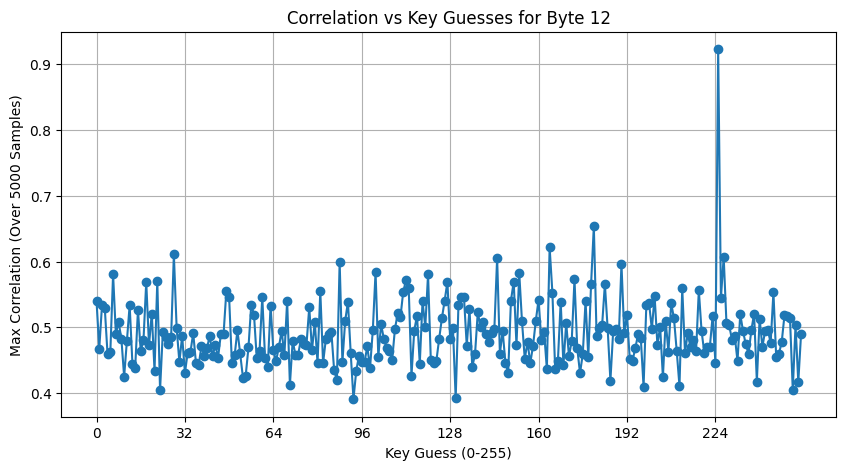

Best guess for key byte 13: 63 , actual keybyte: 63


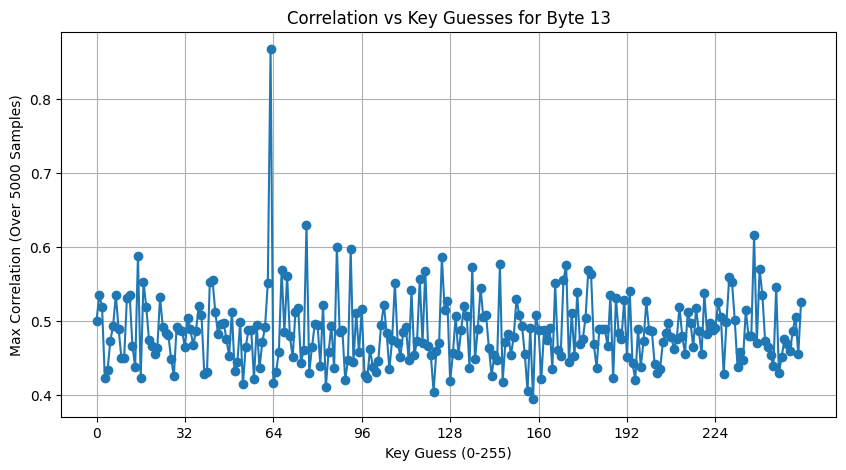

Best guess for key byte 14: 74 , actual keybyte: 74


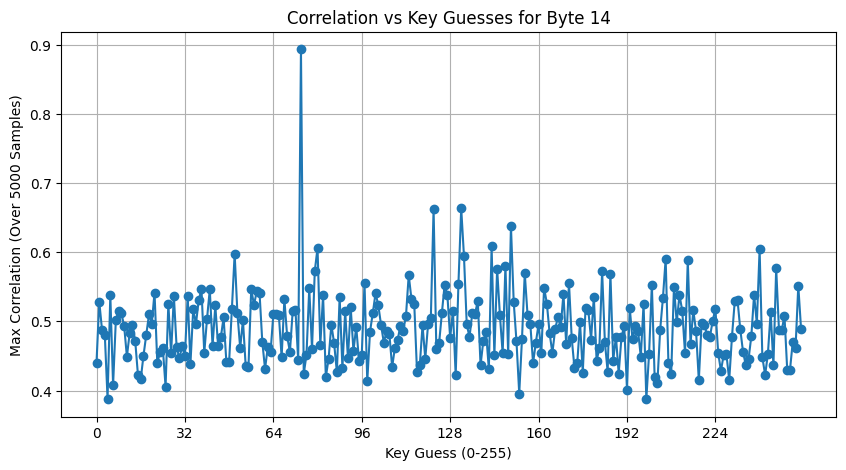

Best guess for key byte 15: 150 , actual keybyte: 150


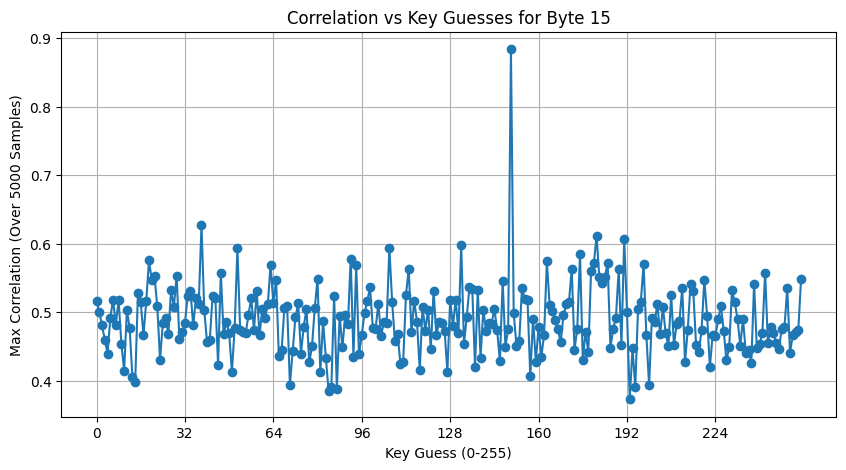

In [253]:
import numpy as np
import matplotlib.pyplot as plt

# CPA Attack Implementation
num_traces, num_samples = trace_array.shape  # (Number of traces, Number of sample points)
num_keys = 256  # AES key bytes range from 0 to 255

key_guesses = np.zeros(16, dtype=int)
all_best_correlations = np.zeros((3, num_keys))  # Store best correlations for the first 3 bytes

best_correlation_for_3_bytes = np.zeros((3, num_keys))  # Store best correlation for the first 3 bytes

for byte in range(16):  # AES has 16 key bytes
    # Hypothetical values matrix
    hypothetical_values = np.zeros((num_traces, num_keys))

    for key_guess in range(num_keys):
        hypothetical_values[:, key_guess] = [sbox[textin_array[i][byte] ^ key_guess] for i in range(num_traces)]

    # Convert to Hamming Weight Model
    hw_model = np.vectorize(lambda x: bin(int(x)).count("1"))(hypothetical_values)

    # Compute correlation for each key hypothesis
    correlation_matrix = getCorrelation(hw_model, trace_array)  # Shape: (256, num_samples)

    # Compute max correlation for each key over 5000 samples
    best_correlation_per_key = np.max(np.abs(correlation_matrix[:, :5000]), axis=1)  # Shape: (256,)

    # Find the best key byte
    key_guesses[byte] = np.argmax(best_correlation_per_key)
    print(f"Best guess for key byte {byte}: {key_guesses[byte]} , actual keybyte: {key_array[0][byte]}")

    # Add first 3 key bytes to the combined plot
    if byte < 3:
        all_best_correlations[byte] = best_correlation_per_key
        # plt.plot(range(256), best_correlation_per_key, label=f'Byte {byte}')
        best_correlation_for_3_bytes[byte] = best_correlation_per_key

    # Create individual plots for each key byte
    plt.figure(figsize=(10, 5))
    plt.plot(range(256), best_correlation_per_key, marker='o', linestyle='-')
    plt.title(f'Correlation vs Key Guesses for Byte {byte}')
    plt.xlabel('Key Guess (0-255)')
    plt.ylabel('Max Correlation (Over 5000 Samples)')
    plt.xticks(np.arange(0, 256, 32))  # Show x-axis labels at intervals
    plt.grid()
    plt.show()



<ipython-input-254-f8ee3416374a>:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


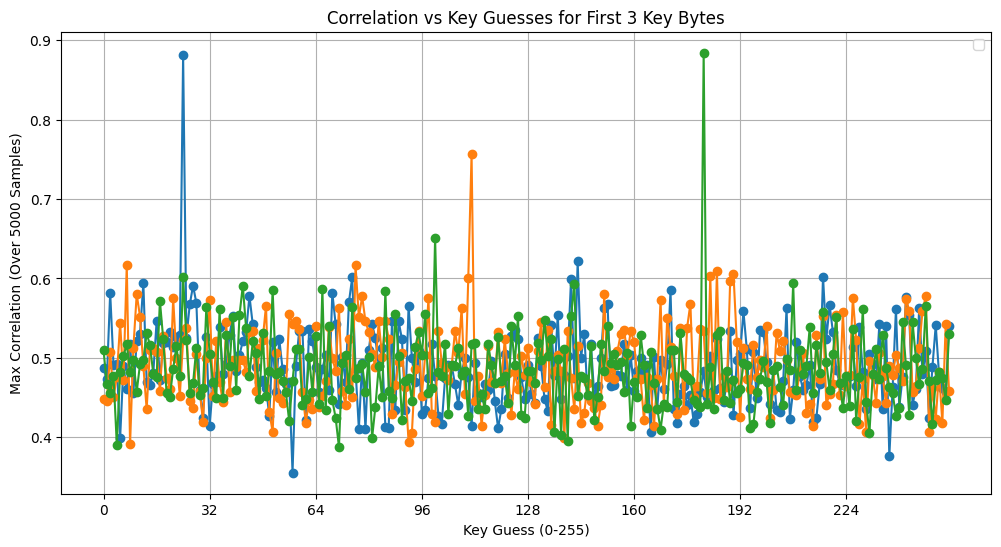

In [254]:
# Final combined plot for first 3 key bytes

plt.figure(figsize=(12, 6))
plt.title('Correlation vs Key Guesses for First 3 Key Bytes')

for i in range(3):
    plt.plot(range(256), best_correlation_for_3_bytes[i],  marker='o', linestyle='-')

plt.xlabel('Key Guess (0-255)')
plt.ylabel('Max Correlation (Over 5000 Samples)')
plt.xticks(np.arange(0, 256, 32))  # Show x-axis labels at intervals
plt.legend()
plt.grid()
plt.show()


In [255]:
#Evaluating accuracy

# Counting the number of correctly guessed bytes
correct_guesses = sum(key_guesses[i] == key_array[0][i] for i in range(len(key_array[0])))
accuracy = (correct_guesses / 16) * 100

print(f"\nCPA Attack Accuracy: {accuracy:.2f}%")



CPA Attack Accuracy: 100.00%


In [256]:
# key = [0] * 18 #assign your guessed key in the key variable.
key = key_guesses

#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
print("Key guess: ", np.array(key))
print("actual key:", key_array[0])
if np.array_equal(np.array(key), key_array[0]):
    print("Keys match!")
else:
    print("Keys do not match.")

Key guess:  [ 24 111 181 111 233  50 246 104   1 132   6 120 225  63  74 150]
actual key: [ 24 111 181 111 233  50 246 104   1 132   6 120 225  63  74 150]
Keys match!
